In [1]:
# Install pycocotools if you haven't yet
# !pip install pycocotools

import os
import torch
import torchvision
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
from PIL import Image
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Set device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [10]:
import re

class MalteseTrafficSignDataset(torch.utils.data.Dataset):
    def __init__(self, root, annotation, transforms=None):
        self.root = root
        self.coco = COCO(annotation)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def _clean_filename(self, json_filename):
        # 1. Try the exact name first
        if os.path.exists(os.path.join(self.root, json_filename)):
            return json_filename
            
        # 2. Try the "Sanitized" version (common in Windows/Linux)
        # Replaces spaces, brackets, and pluses with underscores
        clean_name = json_filename.replace(" ", "_").replace("(", "_").replace(")", "_").replace("+", "_")
        # Remove double underscores that might have been created (e.g. " (2)" -> "__2_")
        while "__" in clean_name:
            clean_name = clean_name.replace("__", "_")
            
        if os.path.exists(os.path.join(self.root, clean_name)):
            return clean_name
            
        # 3. Final Boss: If it still fails, find a partial match in the folder
        # This looks for the first part of the filename (e.g., "WhatsApp_Image_2025")
        try:
            prefix = json_filename.split(' ')[0] # "WhatsApp"
            all_files = os.listdir(self.root)
            for f in all_files:
                # If the image ID or a unique part matches
                if json_filename[:15] in f.replace("_", " "): 
                    return f
        except:
            pass
            
        return json_filename # Fallback

    def __getitem__(self, index):
        img_id = self.ids[index]
        # 1. Get the 'dirty' name from JSON
        original_file_name = self.coco.loadImgs(img_id)[0]['file_name']
        
        # 2. Clean it to match your local files
        cleaned_file_name = self._clean_filename(original_file_name)
        
        # 3. Load using the cleaned path
        full_path = os.path.join(self.root, cleaned_file_name)
        
        if not os.path.exists(full_path):
            # If it still fails, print a warning to help you debug
            print(f"Warning: File not found even after cleaning: {full_path}")
            # Fallback to original just in case
            full_path = os.path.join(self.root, original_file_name)

        img = Image.open(full_path).convert("RGB")

        # ... (rest of your existing __getitem__ code for annotations)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        coco_annotation = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        for ann in coco_annotation:
            xmin, ymin, w, h = ann['bbox']
            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(ann['category_id'])

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_id])
        }

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)

# Helper function for Batching
def collate_fn(batch):
    return tuple(zip(*batch))

In [11]:
# Simple transform to Tensor
transform = T.Compose([T.ToTensor()])

# Training Set
train_dataset = MalteseTrafficSignDataset(
    root="COCO-based_COCO_view_angle/images/train",
    annotation="COCO-based_COCO_view_angle/annotations/train.json",
    transforms=transform
)

# Validation Set
val_dataset = MalteseTrafficSignDataset(
    root="COCO-based_COCO_view_angle/images/val",
    annotation="COCO-based_COCO_view_angle/annotations/val.json",
    transforms=transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [12]:
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    
    # Get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the head
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# num_classes: 0 (BG), 1 (Front), 2 (Back), 3 (Side)
model = get_model(num_classes=4)
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [14]:
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='best_model_checkpoint.pth'):
        """
        patience: How many epochs to wait after last time validation loss improved.
        min_delta: Minimum change in the monitored quantity to qualify as an improvement.
        path: Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased. Saving model to {self.path}')

In [16]:
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='best_model_checkpoint.pth'):
        """
        patience: How many epochs to wait after last time validation loss improved.
        min_delta: Minimum change in the monitored quantity to qualify as an improvement.
        path: Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased. Saving model to {self.path}')

Starting Training on cpu...


Epoch 1/10 [Train]: 100%|█| 117/117 [19:07<00:00,  9.81s/it, total=0.162, cls=0.
Epoch 1/10 [Val]: 100%|█████████| 23/23 [01:07<00:00,  2.94s/it, val_loss=0.348]



Summary Epoch 1:
 > Train Loss: 0.2146 (Avg Cls: 0.0915)
 > Val Loss:   0.1749
Validation loss decreased. Saving model to viewing_angle_best.pth


Epoch 2/10 [Train]: 100%|█| 117/117 [18:42<00:00,  9.59s/it, total=0.100, cls=0.
Epoch 2/10 [Val]: 100%|█████████| 23/23 [01:07<00:00,  2.94s/it, val_loss=0.296]



Summary Epoch 2:
 > Train Loss: 0.1448 (Avg Cls: 0.0672)
 > Val Loss:   0.1472
Validation loss decreased. Saving model to viewing_angle_best.pth


...


Summary Epoch 6:
 > Train Loss: 0.0872 (Avg Cls: 0.0363)
 > Val Loss:   0.1503
EarlyStopping counter: 3 out of 5


Epoch 7/10 [Train]: 100%|█| 117/117 [19:39<00:00, 10.08s/it, total=0.062, cls=0.
Epoch 7/10 [Val]: 100%|█████████| 23/23 [01:12<00:00,  3.14s/it, val_loss=0.316]



Summary Epoch 7:
 > Train Loss: 0.0815 (Avg Cls: 0.0334)
 > Val Loss:   0.1554
EarlyStopping counter: 4 out of 5


Epoch 8/10 [Train]: 100%|█| 117/117 [19:48<00:00, 10.15s/it, total=0.055, cls=0.
Epoch 8/10 [Val]: 100%|█████████| 23/23 [01:10<00:00,  3.05s/it, val_loss=0.269]


Summary Epoch 8:
 > Train Loss: 0.0740 (Avg Cls: 0.0299)
 > Val Loss:   0.1561
EarlyStopping counter: 5 out of 5
!!! Early Stopping Triggered !!!


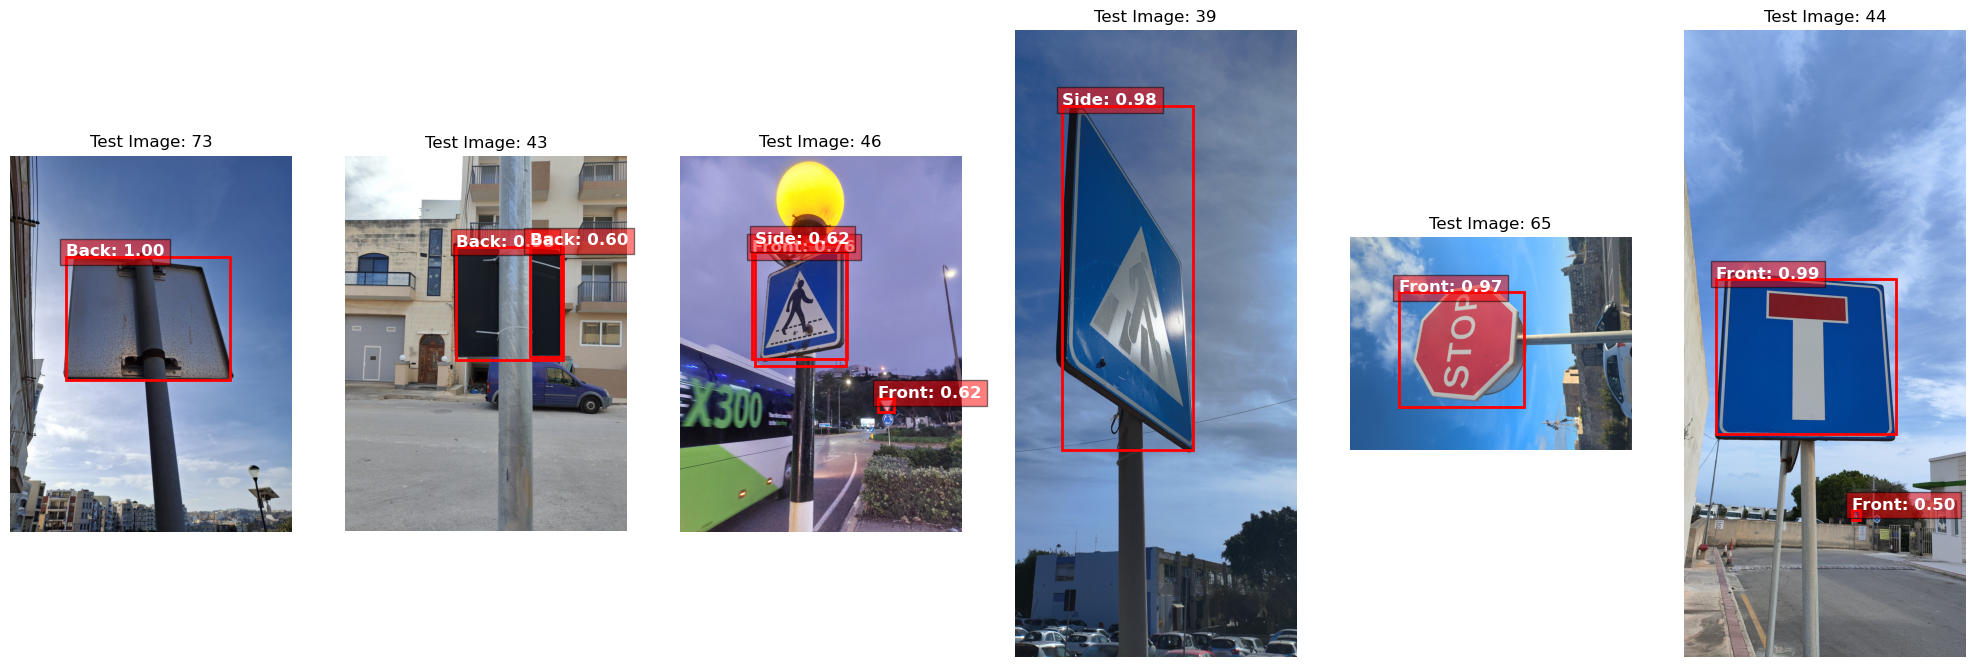

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_prediction(model, dataset, num_images=3):
    model.eval() # Set to evaluation mode
    fig, ax = plt.subplots(1, num_images, figsize=(20, 10))
    
    # Map your class IDs back to text labels
    # 0 is background, 1-3 are your attributes
    label_map = {1: "Back", 2: "Front", 3: "Side"}
    
    # Pick random images from the dataset
    indices = random.sample(range(len(dataset)), num_images)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = dataset[idx]
            # Prediction
            prediction = model([image.to(device)])
            
            # Convert image tensor to numpy for plotting
            img_np = image.permute(1, 2, 0).cpu().numpy()
            
            ax[i].imshow(img_np)
            ax[i].set_title(f"Test Image: {idx}")
            ax[i].axis('off')
            
            # Draw boxes for predictions with confidence > 0.5
            for box, label, score in zip(prediction[0]['boxes'], 
                                         prediction[0]['labels'], 
                                         prediction[0]['scores']):
                if score > 0.5:
                    xmin, ymin, xmax, ymax = box.cpu().numpy()
                    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, 
                                           linewidth=2, edgecolor='r', facecolor='none')
                    ax[i].add_patch(rect)
                    
                    label_text = f"{label_map.get(label.item(), 'Unknown')}: {score:.2f}"
                    ax[i].text(xmin, ymin-5, label_text, color='white', 
                             fontsize=12, fontweight='bold', 
                             bbox=dict(facecolor='red', alpha=0.5))

    plt.tight_layout()
    plt.show()

# Run it on your validation or test dataset
visualize_prediction(model, val_dataset, num_images=6)

In [19]:
# Check what the JSON file thinks the IDs are
print("JSON Categories:", train_dataset.coco.loadCats(train_dataset.coco.getCatIds()))

JSON Categories: [{'id': 1, 'name': 'Back'}, {'id': 2, 'name': 'Front'}, {'id': 3, 'name': 'Side'}]


In [22]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import torch

def evaluate_model(model, data_loader, device):
    model.eval()
    results = []
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)
            
            for i, output in enumerate(outputs):
                image_id = targets[i]["image_id"].item()
                boxes = output["boxes"].cpu().numpy()
                scores = output["scores"].cpu().numpy()
                labels = output["labels"].cpu().numpy()
                
                for box, score, label in zip(boxes, scores, labels):
                    # Convert [x1, y1, x2, y2] to [x, y, w, h] for COCO
                    x1, y1, x2, y2 = box
                    results.append({
                        "image_id": image_id,
                        "category_id": int(label),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(score)
                    })

    # Load ground truth to compare
    coco_gt = val_dataset.coco
    coco_dt = coco_gt.loadRes(results)
    
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

# Run it
evaluate_model(model, val_loader, device)

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.409
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.528
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.426
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.267
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.411
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.506
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.565
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.565
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1